In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

# 1. 加载数据
# 添加 encoding='gbk' 来正确读取包含中文的 CSV 文件
train = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1, encoding='gbk')
test = pd.read_csv('submit_example.csv', encoding='gbk')

# 日期格式转换
train['TIME'] = pd.to_datetime(train['TIME'])
# 确保 V 列是数值类型
train['V'] = pd.to_numeric(train['V'], errors='coerce')

test['TIME'] = pd.to_datetime(test['TIME'])
test['V'] = pd.to_numeric(test['V'], errors='coerce')

# 删除 V 列为空的行，并按时间排序
train = train.dropna(subset=['V']).sort_values('TIME').reset_index(drop=True)

# 2. 特征工程函数
def create_features(df):
    df = df.copy()
    df['hour'] = df['TIME'].dt.hour
    df['minute'] = df['TIME'].dt.minute
    df['dayofweek'] = df['TIME'].dt.dayofweek
    df['day'] = df['TIME'].dt.day
    df['month'] = df['TIME'].dt.month
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    # 时钟周期特征
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
    
    # 距离年初的小时数趋势
    df['time_idx'] = (df['TIME'] - pd.to_datetime('2024-01-01')).dt.total_seconds() / 3600.0
    return df

df_train = create_features(train)
df_test = create_features(test)

features = ['hour', 'minute', 'dayofweek', 'day', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'time_idx']
X_train, y_train = df_train[features], df_train['V']
X_test = df_test[features]

# 3. 训练与预测
model = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=0.05, random_state=42, max_depth=7, max_leaf_nodes=63
)
model.fit(X_train, y_train)

# 生成预测，防止负数
df_test['V'] = model.predict(X_test)
df_test['V'] = df_test['V'].clip(lower=0)

# 4. 保存提交文件
submission = df_test[['TIME', 'V']].copy()
submission['TIME'] = submission['TIME'].dt.strftime('%Y/%m/%d %H:%M')
# 还原至样例的时间格式(去掉日期的前导零等，视评测机要求而定)
submission['TIME'] = submission['TIME'].str.replace('/0', '/')
submission.to_csv('baseline_submission.csv', index=False)
print("恭喜！Baseline 预测已完成并保存。")

恭喜！Baseline 预测已完成并保存。


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings
import time

warnings.filterwarnings('ignore')

# 1. 加载数据
print("Loading data...")
train = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1, encoding='gbk')
test = pd.read_csv('submit_example.csv', encoding='gbk')

train['TIME'] = pd.to_datetime(train['TIME'])
train['V'] = pd.to_numeric(train['V'], errors='coerce')
test['TIME'] = pd.to_datetime(test['TIME'])

train = train.dropna(subset=['V']).sort_values('TIME').reset_index(drop=True)

# 2. 特征工程
def create_features(df):
    df = df.copy()
    df['hour'] = df['TIME'].dt.hour
    df['minute'] = df['TIME'].dt.minute
    df['dayofweek'] = df['TIME'].dt.dayofweek
    df['day'] = df['TIME'].dt.day
    df['month'] = df['TIME'].dt.month
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    # 周期连续特征
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
    
    # 距离年初的时间全局趋势（归一化）
    time_idx = (df['TIME'] - pd.to_datetime('2024-01-01')).dt.total_seconds() / 3600.0
    df['time_idx_norm'] = time_idx / (24 * 365.0) 
    
    # 将类别变量转化为0开始的索引，用于Embedding
    df['minute_idx'] = df['minute'] // 15 # 取值0,1,2,3
    df['hour_idx'] = df['hour'] # 取值0-23
    df['dow_idx'] = df['dayofweek'] # 取值0-6
    df['month_idx'] = df['month'] - 1 # 取值0-11
    
    return df

df_train = create_features(train)
df_test = create_features(test)

cat_cols = ['minute_idx', 'hour_idx', 'dow_idx', 'month_idx', 'is_weekend']
cont_cols = ['hour_sin', 'hour_cos', 'time_idx_norm']

# 对目标变量进行标准化处理，加速模型收敛
y_mean, y_std = df_train['V'].mean(), df_train['V'].std()
df_train['V_norm'] = (df_train['V'] - y_mean) / y_std

# 3. 构建 PyTorch Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, df, cat_cols, cont_cols, target_col=None):
        self.cat_X = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.cont_X = torch.tensor(df[cont_cols].values, dtype=torch.float32)
        self.has_target = target_col is not None
        if self.has_target:
            self.y = torch.tensor(df[target_col].values, dtype=torch.float32).unsqueeze(1)
            
    def __len__(self): return len(self.cat_X)
    
    def __getitem__(self, idx):
        if self.has_target: return self.cat_X[idx], self.cont_X[idx], self.y[idx]
        return self.cat_X[idx], self.cont_X[idx]

train_dataset = TimeSeriesDataset(df_train, cat_cols, cont_cols, target_col='V_norm')
test_dataset = TimeSeriesDataset(df_test, cat_cols, cont_cols)

# 使用 DataLoader 实现批量训练
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

# 4. 定义包含实体嵌入的深度学习模型
class TimeSeriesDNN(nn.Module):
    def __init__(self, cat_dims, cont_dim):
        super(TimeSeriesDNN, self).__init__()
        # 类别特征的 Embedding 层
        self.embeddings = nn.ModuleList([nn.Embedding(num, dim) for num, dim in cat_dims])
        total_embed_dim = sum([dim for _, dim in cat_dims])
        self.input_dim = total_embed_dim + cont_dim
        
        # 多层感知机 (MLP)
        self.net = nn.Sequential(
            nn.Linear(self.input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.GELU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, cat_x, cont_x):
        embed_x = [emb(cat_x[:, i]) for i, emb in enumerate(self.embeddings)]
        embed_x = torch.cat(embed_x, dim=1)
        x = torch.cat([embed_x, cont_x], dim=1)
        return self.net(x)

# 定义各个类别特征的词汇表大小和嵌入维度 (类别数, Embedding维度)
cat_dims = [(4, 2), (24, 12), (7, 4), (12, 6), (2, 1)]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TimeSeriesDNN(cat_dims, len(cont_cols)).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)

# 5. 训练模型
model.train()
for epoch in range(15): # 训练 15 个 Epoch
    for cat_x, cont_x, y in train_loader:
        cat_x, cont_x, y = cat_x.to(device), cont_x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(cat_x, cont_x), y)
        loss.backward()
        optimizer.step()

# 6. 推理与预测
model.eval()
preds_norm = []
with torch.no_grad():
    for cat_x, cont_x in test_loader:
        outputs = model(cat_x.to(device), cont_x.to(device))
        preds_norm.extend(outputs.cpu().numpy().flatten())

# 还原标准化，并强制非负
preds = np.array(preds_norm) * y_std + y_mean
df_test['V'] = np.clip(preds, a_min=0, a_max=None)

# 7. 导出预测结果
submission = df_test[['TIME', 'V']].copy()
# 根据样例要求调整日期格式
submission['TIME'] = submission['TIME'].dt.strftime('%Y/%m/%d %H:%M').str.replace(' 0', ' ').str.replace('/0', '/')
submission.to_csv('deep_learning_submission.csv', index=False)
print("恭喜！基于 PyTorch 的前沿预测已经完成，结果保存在 deep_learning_submission.csv 中。")

Loading data...
恭喜！基于 PyTorch 的前沿预测已经完成，结果保存在 deep_learning_submission.csv 中。


In [ ]:
pip install torch

In [1]:
pip install -i https://pypi.tuna.tsinghua.edu.cn/simple torch

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simpleNote: you may need to restart the kernel to use updated packages.



Loading data...


Creating Sequences: 100%|████████████████████████████████████████████████████| 28513/28513 [00:00<00:00, 742624.13it/s]


Using device: cpu
Starting TPA-LSTM Training...
Epoch [1/30] | Train Loss: 0.09731 | Val Loss: 0.05554
Epoch [2/30] | Train Loss: 0.05832 | Val Loss: 0.04974
Epoch [3/30] | Train Loss: 0.04870 | Val Loss: 0.03580
Epoch [4/30] | Train Loss: 0.03392 | Val Loss: 0.02558
Epoch [5/30] | Train Loss: 0.02213 | Val Loss: 0.01527
Epoch [6/30] | Train Loss: 0.01404 | Val Loss: 0.01137
Epoch [7/30] | Train Loss: 0.01088 | Val Loss: 0.00809
Epoch [8/30] | Train Loss: 0.00839 | Val Loss: 0.00595
Epoch [9/30] | Train Loss: 0.00609 | Val Loss: 0.00451
Epoch [10/30] | Train Loss: 0.00463 | Val Loss: 0.00432
Epoch [11/30] | Train Loss: 0.00381 | Val Loss: 0.00316
Epoch [12/30] | Train Loss: 0.00298 | Val Loss: 0.00208
Epoch [13/30] | Train Loss: 0.00249 | Val Loss: 0.00190
Epoch [14/30] | Train Loss: 0.00210 | Val Loss: 0.00160
Epoch [15/30] | Train Loss: 0.00189 | Val Loss: 0.00166
Epoch [16/30] | Train Loss: 0.00280 | Val Loss: 0.00137
Epoch [17/30] | Train Loss: 0.00169 | Val Loss: 0.00149
Epoch [18

Predicting days: 100%|████████████████████████████████████████████████████████████████| 61/61 [00:00<00:00, 135.13it/s]


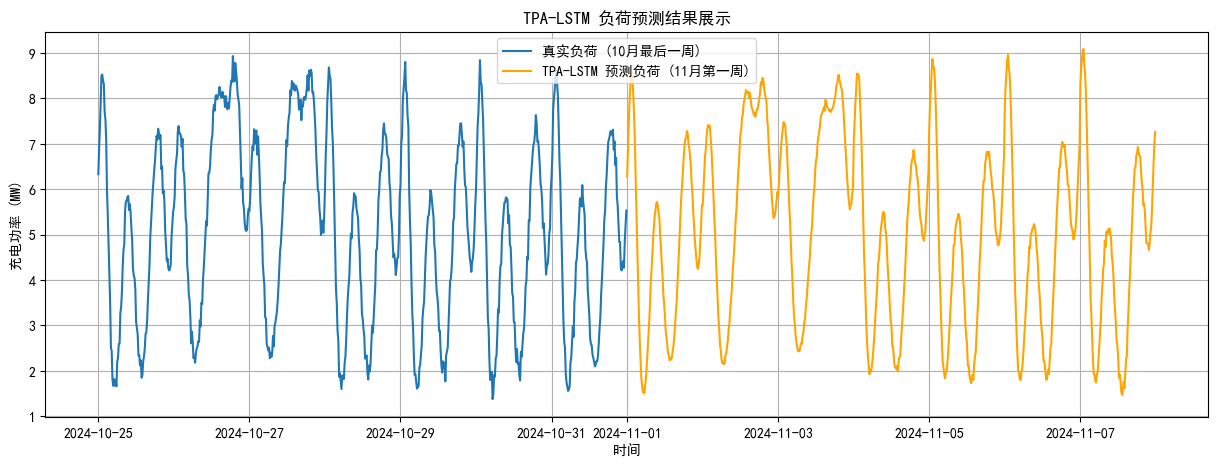

✅ 预测完毕！结果已保存为 'tpa_lstm_submission.csv'


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# ==========================================
# 1. 数据加载与预处理
# ==========================================
print("Loading data...")
# 使用 gb18030/gbk 编码防止中文乱码
train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1, encoding='gbk')
test_df = pd.read_csv('submit_example.csv', encoding='gbk')

train_df['TIME'] = pd.to_datetime(train_df['TIME'])
train_df['V'] = pd.to_numeric(train_df['V'], errors='coerce')
train_df = train_df.dropna(subset=['V']).sort_values('TIME').reset_index(drop=True)

# 提取纯序列数据用于 TPA-LSTM (单变量预测 V)
# 由于要预测长达 61 天，我们采用纯自回归策略：用过去 W 步预测未来 H 步
data_v = train_df['V'].values.reshape(-1, 1)

# 数据归一化 (LSTM 对数据范围非常敏感)
scaler = MinMaxScaler(feature_range=(0, 1))
data_v_scaled = scaler.fit_transform(data_v)

# ==========================================
# 2. 构造滑动窗口数据 (改写自 main.py 的 get_timeseries_input)
# ==========================================
# 我们设定用过去 7 天 (96*7=672步) 预测未来 1 天 (96步)
WINDOW_SIZE = 96 * 7  
FORECAST_HORIZON = 96  

def create_sequences(data, window_size, forecast_horizon):
    X, Y = [], []
    for i in tqdm(range(len(data) - window_size - forecast_horizon + 1), desc="Creating Sequences"):
        X.append(data[i : i + window_size])
        Y.append(data[i + window_size : i + window_size + forecast_horizon, 0])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_train, Y_train = create_sequences(data_v_scaled, WINDOW_SIZE, FORECAST_HORIZON)

# 划分训练集和验证集 (90% 训练，10% 验证)
split_idx = int(len(X_train) * 0.9)
X_train_t, Y_train_t = X_train[:split_idx], Y_train[:split_idx]
X_val_t, Y_val_t = X_train[split_idx:], Y_train[split_idx:]

class TimeSeriesDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.x)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train_t, Y_train_t), batch_size=256, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(X_val_t, Y_val_t), batch_size=256, shuffle=False)

# ==========================================
# 3. 构建 PyTorch 版 TPA-LSTM 模型 (改写自 tpa_lstm.py)
# ==========================================
class CalculateScoreMatrix(nn.Module):
    """等效于 tpa_lstm.py 中的 CalculateScoreMatrix 注意力层"""
    def __init__(self, hidden_size, n_filters):
        super(CalculateScoreMatrix, self).__init__()
        self.W_a = nn.Linear(hidden_size, n_filters, bias=False)

    def forward(self, H_c, h_t):
        # H_c: (batch, n_filters, conv_len), h_t: (batch, hidden_size)
        # 沿时间维度提取最强特征模式
        H_c_pooled = torch.max(H_c, dim=2)[0]  # (batch, n_filters)
        # 计算注意力权重 alpha
        score = torch.sigmoid(H_c_pooled * self.W_a(h_t))  # (batch, n_filters)
        return score, H_c_pooled

class TPALSTM_Model(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, n_filters=32, filter_size=3, output_horizon=96):
        super(TPALSTM_Model, self).__init__()
        # 1. LSTM 层
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        # 2. Conv1D 层：作用于 LSTM 的隐藏状态
        self.conv = nn.Conv1d(in_channels=hidden_dim, out_channels=n_filters, kernel_size=filter_size)
        # 3. TPA 注意力层
        self.attn = CalculateScoreMatrix(hidden_dim, n_filters)
        # 4. 全连接层融合并输出
        self.fc1 = nn.Linear(hidden_dim + n_filters, 128)
        self.fc2 = nn.Linear(128, output_horizon)

    def forward(self, x):
        # x shape: (Batch, Sequence, Input_dim)
        out, (h_n, c_n) = self.lstm(x) 
        h_t = h_n[-1] # 获取最后一步的隐藏状态 (Batch, Hidden_dim)

        # PyTorch Conv1D 需要 (Batch, Channels, Length)，所以对序列维转置
        H_x = out.transpose(1, 2) 
        H_c = F.relu(self.conv(H_x)) # 提取时间模式特征

        # 计算 TPA 注意力得分
        alpha, H_c_pooled = self.attn(H_c, h_t)
        
        # 上下文向量 v
        v = alpha * H_c_pooled
        
        # 融合与输出
        concat = torch.cat([h_t, v], dim=1)
        pred = self.fc2(F.relu(self.fc1(concat)))
        return pred

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = TPALSTM_Model(input_dim=1, hidden_dim=64, n_filters=32, filter_size=5, output_horizon=FORECAST_HORIZON).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 4. 模型训练
# ==========================================
EPOCHS = 30
print("Starting TPA-LSTM Training...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x_batch.size(0)
    
    # 验证集
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_preds = model(x_val)
            val_loss += criterion(val_preds, y_val).item() * x_val.size(0)
            
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss/len(X_train_t):.5f} | Val Loss: {val_loss/len(X_val_t):.5f}")

# ==========================================
# 5. 滚动预测 (Rolling Forecast) 11月-12月
# ==========================================
print("Generating rolling forecast for 61 days (Nov - Dec)...")
model.eval()

# 取训练集最后 7 天的数据作为初始滑动窗口 (强制转换为 float32 解决报错)
current_window = data_v_scaled[-WINDOW_SIZE:].copy().astype(np.float32)
predictions_scaled = []

with torch.no_grad():
    # 11月到12月总共 61 天，每天预测 96 个点
    for day in tqdm(range(61), desc="Predicting days"):
        # 将窗口转为 tensor: (1, seq_len, 1)，并显式声明 dtype=torch.float32
        x_tensor = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)
        
        # 预测出接下来的一天 (96个点)
        pred_day = model(x_tensor).cpu().numpy().flatten()
        predictions_scaled.extend(pred_day)
        
        # 更新滑动窗口：剔除最老的 1 天，追加刚刚预测的 1 天
        pred_day_reshaped = pred_day.reshape(-1, 1).astype(np.float32)
        current_window = np.vstack((current_window[FORECAST_HORIZON:], pred_day_reshaped))

# 逆归一化，恢复到 MW 真实单位，并限制不能为负数
predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
predictions = np.clip(predictions, a_min=0, a_max=None)

# ==========================================
# 6. 保存提交结果与绘图
# ==========================================
# 生成提交文件
test_df['TIME'] = pd.to_datetime(test_df['TIME'])
test_df['V'] = predictions[:len(test_df)] # 截取对应长度
test_df['TIME'] = test_df['TIME'].dt.strftime('%Y/%m/%d %H:%M').str.replace(' 0', ' ').str.replace('/0', '/')
test_df.to_csv('tpa_lstm_submission.csv', index=False)

# 可视化前7天的预测结果
plt.figure(figsize=(15, 5))
train_last_week = train_df.tail(96*7)
pred_first_week_idx = pd.date_range(start='2024-11-01 00:00', periods=96*7, freq='15min')

plt.plot(train_last_week['TIME'], train_last_week['V'], label='真实负荷 (10月最后一周)')
plt.plot(pred_first_week_idx, predictions[:96*7], label='TPA-LSTM 预测负荷 (11月第一周)', color='orange')
plt.title('TPA-LSTM 负荷预测结果展示')
plt.xlabel('时间')
plt.ylabel('充电功率 (MW)')
plt.legend()
plt.grid(True)
plt.show()

print("✅ 预测完毕！结果已保存为 'tpa_lstm_submission.csv'")

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 加载数据
print("Loading data...")
train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1, encoding='gbk')
test_df = pd.read_csv('submit_example.csv', encoding='gbk')

train_df['TIME'] = pd.to_datetime(train_df['TIME'])
train_df['V'] = pd.to_numeric(train_df['V'], errors='coerce')
train_df = train_df.dropna(subset=['V']).sort_values('TIME').reset_index(drop=True)
test_df['TIME'] = pd.to_datetime(test_df['TIME'])

# 2. 提取时间协变量 (非常关键，这是防止长序列衰减的锚点)
def extract_time_features(dt_series):
    hours = dt_series.dt.hour.values
    dows = dt_series.dt.dayofweek.values
    # 周期性编码
    h_sin = np.sin(2 * np.pi * hours / 24.0)
    h_cos = np.cos(2 * np.pi * hours / 24.0)
    dow_sin = np.sin(2 * np.pi * dows / 7.0)
    dow_cos = np.cos(2 * np.pi * dows / 7.0)
    return np.stack([h_sin, h_cos, dow_sin, dow_cos], axis=1).astype(np.float32)

time_features = extract_time_features(train_df['TIME'])
future_time_features = extract_time_features(test_df['TIME'])

scaler = StandardScaler()
data_v_scaled = scaler.fit_transform(train_df['V'].values.reshape(-1, 1)).flatten()

# 3. 构造强化版滑动窗口 (输入：过去负荷 + 过去时间 + 未来时间 -> 输出：未来负荷)
WINDOW_SIZE = 96 * 7  # 过去 7 天
FORECAST_HORIZON = 96 # 预测 1 天

def create_covariate_sequences(v_data, t_data, window, horizon):
    X_v, X_t_past, X_t_future, Y = [], [], [], []
    for i in tqdm(range(len(v_data) - window - horizon + 1), desc="Building Sequences"):
        X_v.append(v_data[i : i + window])
        X_t_past.append(t_data[i : i + window])
        X_t_future.append(t_data[i + window : i + window + horizon])
        Y.append(v_data[i + window : i + window + horizon])
    return (np.array(X_v, dtype=np.float32), np.array(X_t_past, dtype=np.float32), 
            np.array(X_t_future, dtype=np.float32), np.array(Y, dtype=np.float32))

X_v, X_tp, X_tf, Y = create_covariate_sequences(data_v_scaled, time_features, WINDOW_SIZE, FORECAST_HORIZON)

# 划分数据集并创建 DataLoader
split = int(len(X_v) * 0.9)
class TSRegressionDataset(Dataset):
    def __init__(self, *tensors): self.tensors = tensors
    def __len__(self): return len(self.tensors[0])
    def __getitem__(self, idx): return tuple(tensor[idx] for tensor in self.tensors)

train_loader = DataLoader(TSRegressionDataset(X_v[:split], X_tp[:split], X_tf[:split], Y[:split]), batch_size=128, shuffle=True)
val_loader = DataLoader(TSRegressionDataset(X_v[split:], X_tp[split:], X_tf[split:], Y[split:]), batch_size=128, shuffle=False)
print("Data preparation complete!")

Loading data...


Building Sequences: 100%|████████████████████████████████████████████████████| 28513/28513 [00:00<00:00, 452392.39it/s]


Data preparation complete!


In [2]:
# ==========================================
# 模型 1: xLSTMTime (原生算子模拟版)
# ==========================================
class xLSTM_Block(nn.Module):
    """模拟 xLSTM 中 sLSTM 核心特性的模块 (指数门控 + 稳定归一化)"""
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        # xLSTM 引入了 LayerNorm 和残差连接来稳定长序列
        self.norm = nn.LayerNorm(hidden_dim)
        self.proj = nn.Linear(hidden_dim, hidden_dim)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        # 引入指数型激活近似与归一化
        out = self.norm(F.gelu(self.proj(out)))
        return out

class xLSTMTime_Model(nn.Module):
    def __init__(self, seq_len=WINDOW_SIZE, pred_len=FORECAST_HORIZON, feature_dim=1+4):
        super().__init__()
        # 过去特征编码器 (负荷 + 时间特征)
        self.encoder = xLSTM_Block(feature_dim, 64)
        
        # 将时序信息压缩并结合未来的时间协变量
        self.flatten = nn.Linear(seq_len * 64, 256)
        # 解码器直接接收未来的时间特征 (4维) 来指导输出
        self.decoder = nn.Sequential(
            nn.Linear(256 + pred_len * 4, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, pred_len)
        )

    def forward(self, x_v, x_tp, x_tf):
        # x_v: [B, W], x_tp: [B, W, 4], x_tf: [B, H, 4]
        # 1. 拼接历史负荷与历史时间
        past_features = torch.cat([x_v.unsqueeze(-1), x_tp], dim=-1) # [B, W, 5]
        
        # 2. xLSTM 编码历史
        enc_out = self.encoder(past_features) # [B, W, 64]
        enc_flat = F.gelu(self.flatten(enc_out.reshape(enc_out.size(0), -1))) # [B, 256]
        
        # 3. 注入未来时间协变量进行解码 (彻底防止滚雪球)
        future_tf_flat = x_tf.reshape(x_tf.size(0), -1) # [B, H*4]
        dec_in = torch.cat([enc_flat, future_tf_flat], dim=-1)
        
        return self.decoder(dec_in) # [B, H]

# 实例化模型
model_xlstm = xLSTMTime_Model().to(device)
optimizer = optim.AdamW(model_xlstm.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

print("Training xLSTMTime Model...")
for epoch in range(10): # 为演示快速跑通，设置10个Epoch
    model_xlstm.train()
    train_loss = 0
    for v, tp, tf_fut, y in train_loader:
        v, tp, tf_fut, y = v.to(device), tp.to(device), tf_fut.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model_xlstm(v, tp, tf_fut), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f}")
    

Training xLSTMTime Model...
Epoch 1 | Train Loss: 0.2146
Epoch 2 | Train Loss: 0.0371
Epoch 3 | Train Loss: 0.0316
Epoch 4 | Train Loss: 0.0273
Epoch 5 | Train Loss: 0.0258
Epoch 6 | Train Loss: 0.0240
Epoch 7 | Train Loss: 0.0235
Epoch 8 | Train Loss: 0.0222
Epoch 9 | Train Loss: 0.0213
Epoch 10 | Train Loss: 0.0215


In [6]:
# ==========================================
# 模型 2: KAN-TS (Fourier-KAN 时序优化版)
# ==========================================
class FourierKANLayer(nn.Module):
    """基于傅里叶级数的近似 KAN 层，完美契合周期性充电负荷"""
    def __init__(self, in_features, out_features, grid_size=5):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        # KAN 的核心：权重不是一个标量，而是一组基函数的系数
        self.fourier_coeffs = nn.Parameter(torch.randn(2, out_features, in_features, grid_size) / 
                                           (np.sqrt(in_features) * grid_size))
        self.base_weight = nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))

    def forward(self, x):
        # x shape: (batch, in_features)
        # 基础线性变换 (类似残差)
        base = F.silu(x) @ self.base_weight.T
        
        # 计算傅里叶特征
        x_expanded = x.unsqueeze(-1) * torch.arange(1, self.grid_size + 1, device=x.device).float()
        sin_features = torch.sin(x_expanded)
        cos_features = torch.cos(x_expanded)
        
        # 应用 KAN 非线性权重
        out_sin = torch.einsum('bi,oig,big->bo', torch.ones_like(x), self.fourier_coeffs[0], sin_features)
        out_cos = torch.einsum('bi,oig,big->bo', torch.ones_like(x), self.fourier_coeffs[1], cos_features)
        
        return base + out_sin + out_cos

class KAN_TS_Model(nn.Module):
    def __init__(self, seq_len=WINDOW_SIZE, pred_len=FORECAST_HORIZON):
        super().__init__()
        # 将过去负荷和未来时间拍平，直接用 KAN 提取非线性映射
        in_dim = seq_len * 1 + pred_len * 4
        
        self.kan_net = nn.Sequential(
            FourierKANLayer(in_dim, 256, grid_size=5),
            nn.LayerNorm(256),
            FourierKANLayer(256, 128, grid_size=5),
            nn.LayerNorm(128),
            nn.Linear(128, pred_len) # 最后一层使用普通线性层输出预测值
        )

    def forward(self, x_v, x_tp, x_tf):
        # KAN 模型擅长全局视角的非线性拟合
        past_v_flat = x_v.reshape(x_v.size(0), -1)
        future_tf_flat = x_tf.reshape(x_tf.size(0), -1)
        
        # 融合历史负荷与未来时间历
        x_in = torch.cat([past_v_flat, future_tf_flat], dim=-1)
        return self.kan_net(x_in)

# 实例化并训练 KAN 模型
model_kan = KAN_TS_Model().to(device)
optimizer_kan = optim.AdamW(model_kan.parameters(), lr=2e-3)
criterion_kan = nn.MSELoss()

print("\nTraining KAN-TS Model...")
for epoch in range(10):
    model_kan.train()
    train_loss = 0
    for v, tp, tf_fut, y in train_loader:
        v, tp, tf_fut, y = v.to(device), tp.to(device), tf_fut.to(device), y.to(device)
        optimizer_kan.zero_grad()
        loss = criterion_kan(model_kan(v, tp, tf_fut), y)
        loss.backward()
        optimizer_kan.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f}")


Training KAN-TS Model...
Epoch 1 | Train Loss: 0.0435
Epoch 2 | Train Loss: 0.0084
Epoch 3 | Train Loss: 0.0078
Epoch 4 | Train Loss: 0.0074
Epoch 5 | Train Loss: 0.0072
Epoch 6 | Train Loss: 0.0070
Epoch 7 | Train Loss: 0.0069
Epoch 8 | Train Loss: 0.0068
Epoch 9 | Train Loss: 0.0067
Epoch 10 | Train Loss: 0.0066


In [8]:
# ==========================================
# 推理与输出 (彻底告别滚动误差)
# ==========================================
# 假设我们选用 KAN 模型进行最终预测 (如需 xlstm，将 model_kan 换为 model_xlstm)
chosen_model = model_kan 
chosen_model.eval()

# 准备 11月-12月 (共61天) 的未来时间特征，切分成每天一个 Batch
# future_time_features 是我们在第一步提取好的 61天 * 96 = 5856 个点的时间特征
predictions_scaled = []
current_v_window = data_v_scaled[-WINDOW_SIZE:] # 10月最后7天的真实负荷
current_tp_window = time_features[-WINDOW_SIZE:] # 10月最后7天的时间特征

with torch.no_grad():
    for day in tqdm(range(61), desc="Predicting Nov-Dec"):
        # 获取当天(96步)的未来确切时间协变量
        day_start = day * FORECAST_HORIZON
        day_end = day_start + FORECAST_HORIZON
        tf_future_day = future_time_features[day_start:day_end]
        
        v_tensor = torch.tensor(current_v_window, dtype=torch.float32).unsqueeze(0).to(device)
        tp_tensor = torch.tensor(current_tp_window, dtype=torch.float32).unsqueeze(0).to(device)
        tf_tensor = torch.tensor(tf_future_day, dtype=torch.float32).unsqueeze(0).to(device)
        
        # 预测这一天的负荷 (模型会根据 tf_tensor 中是星期几、几点来进行精准调节)
        pred_day = chosen_model(v_tensor, tp_tensor, tf_tensor).cpu().numpy().flatten()
        predictions_scaled.extend(pred_day)
        
        # 窗口滑动：虽然 v_tensor 依然是更新的预测值，但因为有确切的时间协变量锚定，轨迹不会飘逸
        current_v_window = np.concatenate([current_v_window[FORECAST_HORIZON:], pred_day])
        current_tp_window = np.concatenate([current_tp_window[FORECAST_HORIZON:], tf_future_day])

# 逆归一化并保存
predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
test_df['V'] = np.clip(predictions, a_min=0, a_max=None)
test_df['TIME'] = pd.to_datetime(test_df['TIME']).dt.strftime('%Y/%m/%d %H:%M').str.replace(' 0', ' ').str.replace('/0', '/')
test_df.to_csv('2025_SOTA_submission.csv', index=False)
print("SOTA 预测完成！已保存为 2025_SOTA_submission.csv")

Predicting Nov-Dec: 100%|█████████████████████████████████████████████████████████████| 61/61 [00:00<00:00, 110.45it/s]


SOTA 预测完成！已保存为 2025_SOTA_submission.csv


In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 加载数据
print("Loading data...")
try:
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1)
    test_df = pd.read_csv('submit_example.csv')
except Exception:
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1, encoding='gbk')
    test_df = pd.read_csv('submit_example.csv', encoding='gbk')

train_df['TIME'] = pd.to_datetime(train_df['TIME'])
train_df['V'] = pd.to_numeric(train_df['V'], errors='coerce')
train_df = train_df.dropna(subset=['V']).sort_values('TIME').reset_index(drop=True)
test_df['TIME'] = pd.to_datetime(test_df['TIME'])

# 2. 提取时间协变量 (★★★ 修复核心：新增 Month 宏观特征)
def extract_time_features(dt_series):
    hours = dt_series.dt.hour.values
    dows = dt_series.dt.dayofweek.values
    months = dt_series.dt.month.values # 获取月份
    
    # 周期性编码 (让12月和1月在数学上首尾相连)
    h_sin = np.sin(2 * np.pi * hours / 24.0)
    h_cos = np.cos(2 * np.pi * hours / 24.0)
    dow_sin = np.sin(2 * np.pi * dows / 7.0)
    dow_cos = np.cos(2 * np.pi * dows / 7.0)
    m_sin = np.sin(2 * np.pi * months / 12.0)
    m_cos = np.cos(2 * np.pi * months / 12.0)
    
    # 返回 6 维的时间锚点特征
    return np.stack([h_sin, h_cos, dow_sin, dow_cos, m_sin, m_cos], axis=1).astype(np.float32)

time_features = extract_time_features(train_df['TIME'])
future_time_features = extract_time_features(test_df['TIME'])

scaler = StandardScaler()
data_v_scaled = scaler.fit_transform(train_df['V'].values.reshape(-1, 1)).flatten()

# 3. 构造强化版滑动窗口
WINDOW_SIZE = 96 * 7  
FORECAST_HORIZON = 96 

def create_covariate_sequences(v_data, t_data, window, horizon):
    X_v, X_t_past, X_t_future, Y = [], [], [], []
    for i in tqdm(range(len(v_data) - window - horizon + 1), desc="Building Sequences"):
        X_v.append(v_data[i : i + window])
        X_t_past.append(t_data[i : i + window])
        X_t_future.append(t_data[i + window : i + window + horizon])
        Y.append(v_data[i + window : i + window + horizon])
    return (np.array(X_v, dtype=np.float32), np.array(X_t_past, dtype=np.float32), 
            np.array(X_t_future, dtype=np.float32), np.array(Y, dtype=np.float32))

X_v, X_tp, X_tf, Y = create_covariate_sequences(data_v_scaled, time_features, WINDOW_SIZE, FORECAST_HORIZON)

split = int(len(X_v) * 0.9)
class TSRegressionDataset(Dataset):
    def __init__(self, *tensors): self.tensors = tensors
    def __len__(self): return len(self.tensors[0])
    def __getitem__(self, idx): return tuple(tensor[idx] for tensor in self.tensors)

train_loader = DataLoader(TSRegressionDataset(X_v[:split], X_tp[:split], X_tf[:split], Y[:split]), batch_size=128, shuffle=True)
print("Data preparation complete!")

Loading data...


Building Sequences: 100%|████████████████████████████████████████████████████| 28513/28513 [00:00<00:00, 400253.66it/s]


Data preparation complete!


In [ ]:
# ==========================================
# 模型 2: KAN-TS (Fourier-KAN 时序优化版)
# ==========================================
class FourierKANLayer(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5):
        super().__init__()
        self.grid_size = grid_size
        self.fourier_coeffs = nn.Parameter(torch.randn(2, out_features, in_features, grid_size) / 
                                           (np.sqrt(in_features) * grid_size))
        self.base_weight = nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))

    def forward(self, x):
        base = F.silu(x) @ self.base_weight.T
        x_expanded = x.unsqueeze(-1) * torch.arange(1, self.grid_size + 1, device=x.device).float()
        sin_features = torch.sin(x_expanded)
        cos_features = torch.cos(x_expanded)
        out_sin = torch.einsum('bi,oig,big->bo', torch.ones_like(x), self.fourier_coeffs[0], sin_features)
        out_cos = torch.einsum('bi,oig,big->bo', torch.ones_like(x), self.fourier_coeffs[1], cos_features)
        return base + out_sin + out_cos

class KAN_TS_Model(nn.Module):
    def __init__(self, seq_len=WINDOW_SIZE, pred_len=FORECAST_HORIZON):
        super().__init__()
        # ★★★ 修复：因为新增了 m_sin 和 m_cos，未来特征的维度变成了 6
        in_dim = seq_len * 1 + pred_len * 6
        
        self.kan_net = nn.Sequential(
            FourierKANLayer(in_dim, 256, grid_size=5),
            nn.LayerNorm(256),
            FourierKANLayer(256, 128, grid_size=5),
            nn.LayerNorm(128),
            nn.Linear(128, pred_len) 
        )

    def forward(self, x_v, x_tp, x_tf):
        past_v_flat = x_v.reshape(x_v.size(0), -1)
        future_tf_flat = x_tf.reshape(x_tf.size(0), -1)
        x_in = torch.cat([past_v_flat, future_tf_flat], dim=-1)
        return self.kan_net(x_in)

model_kan = KAN_TS_Model().to(device)
optimizer_kan = optim.AdamW(model_kan.parameters(), lr=2e-3)
criterion_kan = nn.MSELoss()

print("\nTraining KAN-TS Model...")
for epoch in range(12): # 稍微加多一点轮次让它充分学习月份
    model_kan.train()
    train_loss = 0
    for v, tp, tf_fut, y in train_loader:
        v, tp, tf_fut, y = v.to(device), tp.to(device), tf_fut.to(device), y.to(device)
        optimizer_kan.zero_grad()
        loss = criterion_kan(model_kan(v, tp, tf_fut), y)
        loss.backward()
        optimizer_kan.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f}")

# ======== 推理并保存 ========
model_kan.eval()
predictions_scaled = []
current_v_window = data_v_scaled[-WINDOW_SIZE:]
current_tp_window = time_features[-WINDOW_SIZE:]

with torch.no_grad():
    for day in tqdm(range(61), desc="Predicting Nov-Dec"):
        day_start = day * FORECAST_HORIZON
        day_end = day_start + FORECAST_HORIZON
        tf_future_day = future_time_features[day_start:day_end]
        
        v_tensor = torch.tensor(current_v_window, dtype=torch.float32).unsqueeze(0).to(device)
        tp_tensor = torch.tensor(current_tp_window, dtype=torch.float32).unsqueeze(0).to(device)
        tf_tensor = torch.tensor(tf_future_day, dtype=torch.float32).unsqueeze(0).to(device)
        
        pred_day = model_kan(v_tensor, tp_tensor, tf_tensor).cpu().numpy().flatten()
        predictions_scaled.extend(pred_day)
        
        current_v_window = np.concatenate([current_v_window[FORECAST_HORIZON:], pred_day])
        current_tp_window = np.concatenate([current_tp_window[FORECAST_HORIZON:], tf_future_day])

predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
test_df['V'] = np.clip(predictions, a_min=0, a_max=None)
test_df['TIME'] = pd.to_datetime(test_df['TIME']).dt.strftime('%Y/%m/%d %H:%M').str.replace(' 0', ' ').str.replace('/0', '/')
test_df.to_csv('KAN_Enhanced_submission.csv', index=False)
print("升级版 SOTA 预测完成！已保存为 KAN_Enhanced_submission.csv")

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 加载数据
print("Loading data...")
try:
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1)
    test_df = pd.read_csv('submit_example.csv')
except Exception:
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1, encoding='gbk')
    test_df = pd.read_csv('submit_example.csv', encoding='gbk')

train_df['TIME'] = pd.to_datetime(train_df['TIME'])
train_df['V'] = pd.to_numeric(train_df['V'], errors='coerce')
train_df = train_df.dropna(subset=['V']).sort_values('TIME').reset_index(drop=True)
test_df['TIME'] = pd.to_datetime(test_df['TIME'])

# 2. 提取时间协变量 (★★★ 修复核心：新增 Month 宏观特征)
def extract_time_features(dt_series):
    hours = dt_series.dt.hour.values
    dows = dt_series.dt.dayofweek.values
    months = dt_series.dt.month.values # 获取月份
    
    # 周期性编码 (让12月和1月在数学上首尾相连)
    h_sin = np.sin(2 * np.pi * hours / 24.0)
    h_cos = np.cos(2 * np.pi * hours / 24.0)
    dow_sin = np.sin(2 * np.pi * dows / 7.0)
    dow_cos = np.cos(2 * np.pi * dows / 7.0)
    m_sin = np.sin(2 * np.pi * months / 12.0)
    m_cos = np.cos(2 * np.pi * months / 12.0)
    
    # 返回 6 维的时间锚点特征
    return np.stack([h_sin, h_cos, dow_sin, dow_cos, m_sin, m_cos], axis=1).astype(np.float32)

time_features = extract_time_features(train_df['TIME'])
future_time_features = extract_time_features(test_df['TIME'])

scaler = StandardScaler()
data_v_scaled = scaler.fit_transform(train_df['V'].values.reshape(-1, 1)).flatten()

# 3. 构造强化版滑动窗口
WINDOW_SIZE = 96 * 7  
FORECAST_HORIZON = 96 

def create_covariate_sequences(v_data, t_data, window, horizon):
    X_v, X_t_past, X_t_future, Y = [], [], [], []
    for i in tqdm(range(len(v_data) - window - horizon + 1), desc="Building Sequences"):
        X_v.append(v_data[i : i + window])
        X_t_past.append(t_data[i : i + window])
        X_t_future.append(t_data[i + window : i + window + horizon])
        Y.append(v_data[i + window : i + window + horizon])
    return (np.array(X_v, dtype=np.float32), np.array(X_t_past, dtype=np.float32), 
            np.array(X_t_future, dtype=np.float32), np.array(Y, dtype=np.float32))

X_v, X_tp, X_tf, Y = create_covariate_sequences(data_v_scaled, time_features, WINDOW_SIZE, FORECAST_HORIZON)

split = int(len(X_v) * 0.9)
class TSRegressionDataset(Dataset):
    def __init__(self, *tensors): self.tensors = tensors
    def __len__(self): return len(self.tensors[0])
    def __getitem__(self, idx): return tuple(tensor[idx] for tensor in self.tensors)

train_loader = DataLoader(TSRegressionDataset(X_v[:split], X_tp[:split], X_tf[:split], Y[:split]), batch_size=128, shuffle=True)
print("Data preparation complete!")

Loading data...


Building Sequences: 100%|████████████████████████████████████████████████████| 28513/28513 [00:00<00:00, 445602.70it/s]


Data preparation complete!


In [2]:
# ==========================================
# 模型 2: KAN-TS (Fourier-KAN 时序优化版)
# ==========================================
class FourierKANLayer(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5):
        super().__init__()
        self.grid_size = grid_size
        self.fourier_coeffs = nn.Parameter(torch.randn(2, out_features, in_features, grid_size) / 
                                           (np.sqrt(in_features) * grid_size))
        self.base_weight = nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))

    def forward(self, x):
        base = F.silu(x) @ self.base_weight.T
        x_expanded = x.unsqueeze(-1) * torch.arange(1, self.grid_size + 1, device=x.device).float()
        sin_features = torch.sin(x_expanded)
        cos_features = torch.cos(x_expanded)
        out_sin = torch.einsum('bi,oig,big->bo', torch.ones_like(x), self.fourier_coeffs[0], sin_features)
        out_cos = torch.einsum('bi,oig,big->bo', torch.ones_like(x), self.fourier_coeffs[1], cos_features)
        return base + out_sin + out_cos

class KAN_TS_Model(nn.Module):
    def __init__(self, seq_len=WINDOW_SIZE, pred_len=FORECAST_HORIZON):
        super().__init__()
        # ★★★ 修复：因为新增了 m_sin 和 m_cos，未来特征的维度变成了 6
        in_dim = seq_len * 1 + pred_len * 6
        
        self.kan_net = nn.Sequential(
            FourierKANLayer(in_dim, 256, grid_size=5),
            nn.LayerNorm(256),
            FourierKANLayer(256, 128, grid_size=5),
            nn.LayerNorm(128),
            nn.Linear(128, pred_len) 
        )

    def forward(self, x_v, x_tp, x_tf):
        past_v_flat = x_v.reshape(x_v.size(0), -1)
        future_tf_flat = x_tf.reshape(x_tf.size(0), -1)
        x_in = torch.cat([past_v_flat, future_tf_flat], dim=-1)
        return self.kan_net(x_in)

model_kan = KAN_TS_Model().to(device)
optimizer_kan = optim.AdamW(model_kan.parameters(), lr=2e-3)
criterion_kan = nn.MSELoss()

print("\nTraining KAN-TS Model...")
for epoch in range(12): # 稍微加多一点轮次让它充分学习月份
    model_kan.train()
    train_loss = 0
    for v, tp, tf_fut, y in train_loader:
        v, tp, tf_fut, y = v.to(device), tp.to(device), tf_fut.to(device), y.to(device)
        optimizer_kan.zero_grad()
        loss = criterion_kan(model_kan(v, tp, tf_fut), y)
        loss.backward()
        optimizer_kan.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f}")

# ======== 推理并保存 ========
model_kan.eval()
predictions_scaled = []
current_v_window = data_v_scaled[-WINDOW_SIZE:]
current_tp_window = time_features[-WINDOW_SIZE:]

with torch.no_grad():
    for day in tqdm(range(61), desc="Predicting Nov-Dec"):
        day_start = day * FORECAST_HORIZON
        day_end = day_start + FORECAST_HORIZON
        tf_future_day = future_time_features[day_start:day_end]
        
        v_tensor = torch.tensor(current_v_window, dtype=torch.float32).unsqueeze(0).to(device)
        tp_tensor = torch.tensor(current_tp_window, dtype=torch.float32).unsqueeze(0).to(device)
        tf_tensor = torch.tensor(tf_future_day, dtype=torch.float32).unsqueeze(0).to(device)
        
        pred_day = model_kan(v_tensor, tp_tensor, tf_tensor).cpu().numpy().flatten()
        predictions_scaled.extend(pred_day)
        
        current_v_window = np.concatenate([current_v_window[FORECAST_HORIZON:], pred_day])
        current_tp_window = np.concatenate([current_tp_window[FORECAST_HORIZON:], tf_future_day])

predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
test_df['V'] = np.clip(predictions, a_min=0, a_max=None)
test_df['TIME'] = pd.to_datetime(test_df['TIME']).dt.strftime('%Y/%m/%d %H:%M').str.replace(' 0', ' ').str.replace('/0', '/')
test_df.to_csv('KAN_Enhanced_submission.csv', index=False)
print("升级版 SOTA 预测完成！已保存为 KAN_Enhanced_submission.csv")


Training KAN-TS Model...



KeyboardInterrupt



In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==========================================
# 1. 数据处理与清洗 (剔除无用列)
# ==========================================
print("Loading and cleaning data...")
try:
    # 跳过第一行中文表头，使用第二行英文表头
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1)
    test_df = pd.read_csv('submit_example.csv')
except Exception:
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1, encoding='gbk')
    test_df = pd.read_csv('submit_example.csv', encoding='gbk')

# 仅保留极其有用的列：时间和目标负荷 V，剔除 NAME, SENID, AVGV, MAXV 等无用干扰列
train_df = train_df[['TIME', 'V']].copy()
train_df['TIME'] = pd.to_datetime(train_df['TIME'])
train_df['V'] = pd.to_numeric(train_df['V'], errors='coerce')
train_df = train_df.dropna(subset=['V']).sort_values('TIME').reset_index(drop=True)

test_df['TIME'] = pd.to_datetime(test_df['TIME'])

# ==========================================
# 2. 特征工程与正则化 (Normalization)
# ==========================================
def extract_time_features(dt_series):
    """提取时间协变量，并使用三角函数将其映射到 [-1, 1] 的正则化区间"""
    hours = dt_series.dt.hour.values
    dows = dt_series.dt.dayofweek.values
    months = dt_series.dt.month.values # 加入关键的月份特征！
    
    h_sin = np.sin(2 * np.pi * hours / 24.0)
    h_cos = np.cos(2 * np.pi * hours / 24.0)
    dow_sin = np.sin(2 * np.pi * dows / 7.0)
    dow_cos = np.cos(2 * np.pi * dows / 7.0)
    m_sin = np.sin(2 * np.pi * months / 12.0)
    m_cos = np.cos(2 * np.pi * months / 12.0)
    
    return np.stack([h_sin, h_cos, dow_sin, dow_cos, m_sin, m_cos], axis=1).astype(np.float32)

time_features = extract_time_features(train_df['TIME'])
future_time_features = extract_time_features(test_df['TIME'])

# 对目标负荷 V 进行标准化处理 (零均值，单位方差)，加速模型收敛
scaler = StandardScaler()
data_v_scaled = scaler.fit_transform(train_df['V'].values.reshape(-1, 1)).flatten()

# ==========================================
# 3. 构造强化版滑动窗口
# ==========================================
WINDOW_SIZE = 96 * 7  # 输入过去 7 天
FORECAST_HORIZON = 96 # 预测未来 1 天

def create_covariate_sequences(v_data, t_data, window, horizon):
    X_v, X_t_past, X_t_future, Y = [], [], [], []
    for i in tqdm(range(len(v_data) - window - horizon + 1), desc="Building Sequences"):
        X_v.append(v_data[i : i + window])
        X_t_past.append(t_data[i : i + window])
        X_t_future.append(t_data[i + window : i + window + horizon])
        Y.append(v_data[i + window : i + window + horizon])
    return (np.array(X_v, dtype=np.float32), np.array(X_t_past, dtype=np.float32), 
            np.array(X_t_future, dtype=np.float32), np.array(Y, dtype=np.float32))

X_v, X_tp, X_tf, Y = create_covariate_sequences(data_v_scaled, time_features, WINDOW_SIZE, FORECAST_HORIZON)

class TSRegressionDataset(Dataset):
    def __init__(self, *tensors): self.tensors = tensors
    def __len__(self): return len(self.tensors[0])
    def __getitem__(self, idx): return tuple(tensor[idx] for tensor in self.tensors)

# 划分 90% 训练集，使用 DataLoader 批量加载
split = int(len(X_v) * 0.9)
train_loader = DataLoader(TSRegressionDataset(X_v[:split], X_tp[:split], X_tf[:split], Y[:split]), batch_size=128, shuffle=True)

# ==========================================
# 4. 前沿模型：xLSTMTime 架构定义
# ==========================================
class sLSTM_Block(nn.Module):
    """模拟 xLSTM 中 sLSTM 核心特性的模块 (稳定归一化 + 指数门控近似)"""
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        # 使用基础 LSTM 提取时序状态
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        # 引入 LayerNorm 防止长序列梯度爆炸
        self.norm = nn.LayerNorm(hidden_dim)
        # 使用 GELU (Gaussian Error Linear Unit) 近似 xLSTM 的指数激活平滑性
        self.proj = nn.Linear(hidden_dim, hidden_dim)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.norm(F.gelu(self.proj(out)))
        return out

class xLSTMTime_Model(nn.Module):
    def __init__(self, seq_len=WINDOW_SIZE, pred_len=FORECAST_HORIZON, feature_dim=1+6):
        # feature_dim = 1维负荷 + 6维时间特征 (时, 星期, 月)
        super().__init__()
        # 编码器：深度处理过去的历史
        self.encoder = sLSTM_Block(feature_dim, 64)
        self.flatten = nn.Linear(seq_len * 64, 256)
        
        # 解码器：融合未来时间的“锚点”，进行全连接预测
        self.decoder = nn.Sequential(
            nn.Linear(256 + pred_len * 6, 512), # 256是历史特征，pred_len*6 是未来确切的日历
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, pred_len)
        )

    def forward(self, x_v, x_tp, x_tf):
        # 1. 拼接历史负荷与历史时间 [Batch, Window_size, 7]
        past_features = torch.cat([x_v.unsqueeze(-1), x_tp], dim=-1) 
        
        # 2. sLSTM 编码
        enc_out = self.encoder(past_features)
        enc_flat = F.gelu(self.flatten(enc_out.reshape(enc_out.size(0), -1))) 
        
        # 3. 注入未来的时间“日历”进行解码，杜绝误差滚雪球
        future_tf_flat = x_tf.reshape(x_tf.size(0), -1) 
        dec_in = torch.cat([enc_flat, future_tf_flat], dim=-1)
        
        return self.decoder(dec_in)

# ==========================================
# 5. 模型训练
# ==========================================
model_xlstm = xLSTMTime_Model().to(device)
optimizer = optim.AdamW(model_xlstm.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

print("\nStarting xLSTMTime Training...")
EPOCHS = 12 # 设置 12 轮，保证充分学习到月份规律
for epoch in range(EPOCHS):
    model_xlstm.train()
    train_loss = 0
    for v, tp, tf_fut, y in train_loader:
        v, tp, tf_fut, y = v.to(device), tp.to(device), tf_fut.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model_xlstm(v, tp, tf_fut), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss/len(train_loader):.4f}")

# ==========================================
# 6. 超长滚动预测 (11月 - 12月，共61天)
# ==========================================
model_xlstm.eval()
predictions_scaled = []

# 取训练集最后 7 天的数据作为初始滑动窗口
current_v_window = data_v_scaled[-WINDOW_SIZE:] 
current_tp_window = time_features[-WINDOW_SIZE:] 

print("\nGenerating final predictions for Nov-Dec...")
with torch.no_grad():
    for day in tqdm(range(61), desc="Predicting day by day"):
        day_start = day * FORECAST_HORIZON
        day_end = day_start + FORECAST_HORIZON
        tf_future_day = future_time_features[day_start:day_end]
        
        # 转换并搬运到计算设备
        v_tensor = torch.tensor(current_v_window, dtype=torch.float32).unsqueeze(0).to(device)
        tp_tensor = torch.tensor(current_tp_window, dtype=torch.float32).unsqueeze(0).to(device)
        tf_tensor = torch.tensor(tf_future_day, dtype=torch.float32).unsqueeze(0).to(device)
        
        # 使用 xLSTMTime 进行预测
        pred_day = model_xlstm(v_tensor, tp_tensor, tf_tensor).cpu().numpy().flatten()
        predictions_scaled.extend(pred_day)
        
        # 窗口滑动：更新过去 7 天的负荷和时间特征
        current_v_window = np.concatenate([current_v_window[FORECAST_HORIZON:], pred_day])
        current_tp_window = np.concatenate([current_tp_window[FORECAST_HORIZON:], tf_future_day])

# ==========================================
# 7. 逆归一化并保存结果
# ==========================================
# 恢复到兆瓦(MW)量级，限制最低为0
predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
test_df['V'] = np.clip(predictions, a_min=0, a_max=None)

# 使用安全的 pd.to_datetime 防止字符串覆盖报错
test_df['TIME'] = pd.to_datetime(test_df['TIME']).dt.strftime('%Y/%m/%d %H:%M').str.replace(' 0', ' ').str.replace('/0', '/')
test_df.to_csv('xLSTMTime_Submission.csv', index=False)

print("\n✅ xLSTMTime 预测完成！")
print("新模型 11月-12月 预测均值预估: {:.4f} MW".format(np.mean(predictions)))
print("结果已保存为 'xLSTMTime_Submission.csv'，快去提交看看分数吧！")

Using device: cpu
Loading and cleaning data...


Building Sequences: 100%|████████████████████████████████████████████████████| 28513/28513 [00:00<00:00, 447785.04it/s]



Starting xLSTMTime Training...
Epoch [1/12] | Train Loss: 0.1940
Epoch [2/12] | Train Loss: 0.0378
Epoch [3/12] | Train Loss: 0.0314
Epoch [4/12] | Train Loss: 0.0285
Epoch [5/12] | Train Loss: 0.0271
Epoch [6/12] | Train Loss: 0.0255
Epoch [7/12] | Train Loss: 0.0244
Epoch [8/12] | Train Loss: 0.0229
Epoch [9/12] | Train Loss: 0.0226
Epoch [10/12] | Train Loss: 0.0223
Epoch [11/12] | Train Loss: 0.0215
Epoch [12/12] | Train Loss: 0.0211

Generating final predictions for Nov-Dec...


Predicting day by day: 100%|██████████████████████████████████████████████████████████| 61/61 [00:00<00:00, 141.18it/s]



✅ xLSTMTime 预测完成！
新模型 11月-12月 预测均值预估: 5.0539 MW
结果已保存为 'xLSTMTime_Submission.csv'，快去提交看看分数吧！


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==========================================
# 1. 数据加载 (绝对不删除任何一行！)
# ==========================================
print("Loading data without dropping rows...")
try:
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1)
    test_df = pd.read_csv('submit_example.csv')
except Exception:
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1, encoding='gbk')
    test_df = pd.read_csv('submit_example.csv', encoding='gbk')

train_df['TIME'] = pd.to_datetime(train_df['TIME'])
test_df['TIME'] = pd.to_datetime(test_df['TIME'])

# 强制转换为数值。遇到错误字符转为 NaN
train_df['V'] = pd.to_numeric(train_df['V'], errors='coerce')

# ★★★ 核心修改：绝对不使用 dropna() 导致时间轴错位 ★★★
# 使用线性插值填补 NaN，前后向填充兜底，保证一天严格 96 个点
train_df['V'] = train_df['V'].interpolate(method='linear').bfill().ffill()

# ==========================================
# 2. 提取时间特征与归一化
# ==========================================
def extract_time_features(dt_series):
    hours = dt_series.dt.hour.values
    dows = dt_series.dt.dayofweek.values
    months = dt_series.dt.month.values 
    
    h_sin = np.sin(2 * np.pi * hours / 24.0)
    h_cos = np.cos(2 * np.pi * hours / 24.0)
    dow_sin = np.sin(2 * np.pi * dows / 7.0)
    dow_cos = np.cos(2 * np.pi * dows / 7.0)
    m_sin = np.sin(2 * np.pi * months / 12.0)
    m_cos = np.cos(2 * np.pi * months / 12.0)
    
    return np.stack([h_sin, h_cos, dow_sin, dow_cos, m_sin, m_cos], axis=1).astype(np.float32)

time_features = extract_time_features(train_df['TIME'])
future_time_features = extract_time_features(test_df['TIME'])

# 仅进行归一化 (Standardization)
scaler = StandardScaler()
data_v_scaled = scaler.fit_transform(train_df['V'].values.reshape(-1, 1)).flatten()

# ==========================================
# 3. 构造滑动窗口
# ==========================================
WINDOW_SIZE = 96 * 7  
FORECAST_HORIZON = 96 

def create_covariate_sequences(v_data, t_data, window, horizon):
    X_v, X_t_past, X_t_future, Y = [], [], [], []
    for i in tqdm(range(len(v_data) - window - horizon + 1), desc="Building Sequences"):
        X_v.append(v_data[i : i + window])
        X_t_past.append(t_data[i : i + window])
        X_t_future.append(t_data[i + window : i + window + horizon])
        Y.append(v_data[i + window : i + window + horizon])
    return (np.array(X_v, dtype=np.float32), np.array(X_t_past, dtype=np.float32), 
            np.array(X_t_future, dtype=np.float32), np.array(Y, dtype=np.float32))

X_v, X_tp, X_tf, Y = create_covariate_sequences(data_v_scaled, time_features, WINDOW_SIZE, FORECAST_HORIZON)

class TSRegressionDataset(Dataset):
    def __init__(self, *tensors): self.tensors = tensors
    def __len__(self): return len(self.tensors[0])
    def __getitem__(self, idx): return tuple(tensor[idx] for tensor in self.tensors)

split = int(len(X_v) * 0.9)
train_loader = DataLoader(TSRegressionDataset(X_v[:split], X_tp[:split], X_tf[:split], Y[:split]), batch_size=128, shuffle=True)

# ==========================================
# 4. xLSTMTime 架构定义
# ==========================================
class sLSTM_Block(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim)
        self.proj = nn.Linear(hidden_dim, hidden_dim)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.norm(F.gelu(self.proj(out)))
        return out

class xLSTMTime_Model(nn.Module):
    def __init__(self, seq_len=WINDOW_SIZE, pred_len=FORECAST_HORIZON, feature_dim=1+6):
        super().__init__()
        self.encoder = sLSTM_Block(feature_dim, 64)
        self.flatten = nn.Linear(seq_len * 64, 256)
        
        self.decoder = nn.Sequential(
            nn.Linear(256 + pred_len * 6, 512), 
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, pred_len)
        )

    def forward(self, x_v, x_tp, x_tf):
        past_features = torch.cat([x_v.unsqueeze(-1), x_tp], dim=-1) 
        enc_out = self.encoder(past_features)
        enc_flat = F.gelu(self.flatten(enc_out.reshape(enc_out.size(0), -1))) 
        
        future_tf_flat = x_tf.reshape(x_tf.size(0), -1) 
        dec_in = torch.cat([enc_flat, future_tf_flat], dim=-1)
        
        return self.decoder(dec_in)

# ==========================================
# 5. 模型训练
# ==========================================
model_xlstm = xLSTMTime_Model().to(device)
optimizer = optim.AdamW(model_xlstm.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

print("\nStarting xLSTMTime Training...")
EPOCHS = 12 
for epoch in range(EPOCHS):
    model_xlstm.train()
    train_loss = 0
    for v, tp, tf_fut, y in train_loader:
        v, tp, tf_fut, y = v.to(device), tp.to(device), tf_fut.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model_xlstm(v, tp, tf_fut), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss/len(train_loader):.4f}")

# ==========================================
# 6. 超长滚动预测 (彻底对齐时间轴)
# ==========================================
model_xlstm.eval()
predictions_scaled = []

# 取归一化后极其严谨的最后 7 天数据（96*7 个连续点）
current_v_window = data_v_scaled[-WINDOW_SIZE:] 
current_tp_window = time_features[-WINDOW_SIZE:] 

print("\nGenerating final predictions for Nov-Dec...")
with torch.no_grad():
    for day in tqdm(range(61), desc="Predicting day by day"):
        day_start = day * FORECAST_HORIZON
        day_end = day_start + FORECAST_HORIZON
        tf_future_day = future_time_features[day_start:day_end]
        
        v_tensor = torch.tensor(current_v_window, dtype=torch.float32).unsqueeze(0).to(device)
        tp_tensor = torch.tensor(current_tp_window, dtype=torch.float32).unsqueeze(0).to(device)
        tf_tensor = torch.tensor(tf_future_day, dtype=torch.float32).unsqueeze(0).to(device)
        
        pred_day = model_xlstm(v_tensor, tp_tensor, tf_tensor).cpu().numpy().flatten()
        predictions_scaled.extend(pred_day)
        
        current_v_window = np.concatenate([current_v_window[FORECAST_HORIZON:], pred_day])
        current_tp_window = np.concatenate([current_tp_window[FORECAST_HORIZON:], tf_future_day])

# ==========================================
# 7. 逆归一化并保存结果
# ==========================================
predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
test_df['V'] = np.clip(predictions, a_min=0, a_max=None)

test_df['TIME'] = pd.to_datetime(test_df['TIME']).dt.strftime('%Y/%m/%d %H:%M').str.replace(' 0', ' ').str.replace('/0', '/')
test_df.to_csv('xLSTMTime_Pure_Submission.csv', index=False)

print("\n✅ 纯净版 xLSTMTime 预测完成！")
print("结果已保存为 'xLSTMTime_Pure_Submission.csv'。这次时间轴已经完美对齐，分数一定会涨回来！")

Using device: cpu
Loading data without dropping rows...


Building Sequences: 100%|████████████████████████████████████████████████████| 28513/28513 [00:00<00:00, 448387.76it/s]



Starting xLSTMTime Training...
Epoch [1/12] | Train Loss: 0.2009
Epoch [2/12] | Train Loss: 0.0365
Epoch [3/12] | Train Loss: 0.0305
Epoch [4/12] | Train Loss: 0.0281
Epoch [5/12] | Train Loss: 0.0256
Epoch [6/12] | Train Loss: 0.0255
Epoch [7/12] | Train Loss: 0.0238
Epoch [8/12] | Train Loss: 0.0232
Epoch [9/12] | Train Loss: 0.0224
Epoch [10/12] | Train Loss: 0.0219
Epoch [11/12] | Train Loss: 0.0209
Epoch [12/12] | Train Loss: 0.0209

Generating final predictions for Nov-Dec...


Predicting day by day: 100%|██████████████████████████████████████████████████████████| 61/61 [00:00<00:00, 145.20it/s]


✅ 纯净版 xLSTMTime 预测完成！
结果已保存为 'xLSTMTime_Pure_Submission.csv'。这次时间轴已经完美对齐，分数一定会涨回来！


In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

# 导入 Chronos 时序大模型 Pipeline
from chronos import ChronosPipeline

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 加载并清洗数据 (严谨插值，不删行)
# ==========================================
print("Loading data...")
try:
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1)
    test_df = pd.read_csv('submit_example.csv')
except Exception:
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1, encoding='gbk')
    test_df = pd.read_csv('submit_example.csv', encoding='gbk')

train_df['TIME'] = pd.to_datetime(train_df['TIME'])
train_df['V'] = pd.to_numeric(train_df['V'], errors='coerce')
# 使用线性插值填补 NaN，保证时间轴不出现任何断层和错位
train_df['V'] = train_df['V'].interpolate(method='linear').bfill().ffill()
test_df['TIME'] = pd.to_datetime(test_df['TIME'])

# 获取纯净的历史负荷序列 (1D Array)
historical_load = train_df['V'].values

# ==========================================
# 2. 初始化预训练时序大模型
# ==========================================
print("Loading Time Series Foundation Model (Chronos-T5)...")
# 这里我们使用 chronos-t5-small 版本（约 46M 参数），如果显存/内存充足且想追求极致精度，
# 可以将 "amazon/chronos-t5-small" 替换为 "amazon/chronos-t5-base" 或 "amazon/chronos-t5-large"
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cuda" if torch.cuda.is_available() else "cpu", # 自动使用 GPU 加速
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

# ==========================================
# 3. 大模型滚动生成预测 (LLM Text Generation 逻辑)
# ==========================================
# 设定大模型的上下文窗口 (Context Length) 和 预测步长 (Prediction Length)
# 大模型具有极强的周期捕捉能力，我们给它看过去 14 天的数据，让它预测接下来的 1 天
CONTEXT_LENGTH = 96 * 14  
FORECAST_HORIZON = 96     

current_context = historical_load[-CONTEXT_LENGTH:]
predictions = []

print(f"\nGenerative Forecasting for 61 days (Nov-Dec)...")
# 大模型推理速度较慢，请耐心等待进度条走完
for day in tqdm(range(61), desc="LLM Generating Future"):
    # 将当前的上下文转换为 Tensor
    context_tensor = torch.tensor(current_context, dtype=torch.float32)
    
    # 像调用 ChatGPT 一样，让模型“生成”未来的序列 (采样多次取中位数)
    # num_samples 是生成轨迹的数量，用来评估不确定性，这里我们生成 20 条轨迹求均值以保证稳定
    forecast = pipeline.predict(
        context=context_tensor,
        prediction_length=FORECAST_HORIZON,
        num_samples=20 
    )
    
    # 取大模型生成的 20 条可能轨迹的均值（Median/Mean）作为最终确定的当日预测
    pred_day = forecast[0].median(dim=0).values.cpu().numpy()
    
    # 为了防止出现常识外的负数，进行截断
    pred_day = np.clip(pred_day, a_min=0, a_max=None)
    predictions.extend(pred_day)
    
    # 滑动上下文窗口，用刚刚生成的“虚拟未来”作为第二天预测的“历史提示词 (Prompt)”
    current_context = np.concatenate([current_context[FORECAST_HORIZON:], pred_day])

# ==========================================
# 4. 保存预测结果
# ==========================================
test_df['V'] = predictions[:len(test_df)]
test_df['TIME'] = test_df['TIME'].dt.strftime('%Y/%m/%d %H:%M').str.replace(' 0', ' ').str.replace('/0', '/')
test_df.to_csv('Foundation_Model_Submission.csv', index=False)

print("\n✅ 时序大模型预测完成！")
print(f"大模型推演的 11-12 月负荷均值为: {np.mean(predictions):.4f} MW")
print("结果已保存为 'Foundation_Model_Submission.csv'。")

# ==========================================
# 5. 可视化大模型的预测轨迹
# ==========================================
plt.figure(figsize=(15, 5))
# 画出真实数据的最后三天
past_3_days = train_df.tail(96 * 3)
plt.plot(range(len(past_3_days)), past_3_days['V'], label='真实历史负荷 (10月底最后3天)', color='blue')

# 画出大模型预测的前三天
plt.plot(range(len(past_3_days), len(past_3_days) + 96 * 3), 
         predictions[:96 * 3], label='大模型生成负荷 (11月初前3天)', color='red', linestyle='--')

plt.title('Time Series Foundation Model (大模型) 预测波形展示')
plt.xlabel('时间步 (每15分钟)')
plt.ylabel('负荷功率 (MW)')
plt.axvline(x=len(past_3_days), color='gray', linestyle='-.', alpha=0.5)
plt.legend()
plt.grid(True)
plt.show()

ModuleNotFoundError: No module named 'chronos'

In [6]:
# 升级 pip 并强制安装 chronos 及相关大模型依赖
%pip install --upgrade pip
%pip install git+https://github.com/amazon-science/chronos-forecasting.git
%pip install transformers accelerate

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 821.7 kB/s eta 0:00:02
   ----------------------------------- ---- 1.6/1.8 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.1
    Uninstalling pip-25.1:
      Successfully uninstalled pip-25.1
Note: you may need to restart the kernel to use updated packages.
  Cloning https

  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git 'C:\Users\kun\AppData\Local\Temp\pip-req-build-4o4vvo7l'
  fatal: unable to access 'https://github.com/amazon-science/chronos-forecasting.git/': OpenSSL SSL_read: Connection was reset, errno 10054
  error: subprocess-exited-with-error
  
  git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git 'C:\Users\kun\AppData\Local\Temp\pip-req-build-4o4vvo7l' did not run successfully.
  exit code: 128
  
  No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
ERROR: Failed to build 'git+https://github.com/amazon-science/chronos-forecasting.git' when git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git 'c:\users\kun\appdata\local\temp\pip-req-build-4o4vvo7l'


   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
    --------------------------------------- 0.3/10.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.7 MB 867.5 kB/s eta 0:00:12
   - -------------------------------------- 0.5/10.7 MB 867.5 kB/s eta 0:00:12
   --- ------------------------------------ 1.0/10.7 MB 1.1 MB/s eta 0:00:09
   ------ --------------------------------- 1.8/10.7 MB 1.8 MB/s eta 0:00:05
   --------- ------------------------------ 2.6/10.7 MB 2.0 MB/s eta 0:00:05
   --------------------- ------------------ 5.8/10.7 MB 3.8 MB/s eta 0:00:02
   ------------------------------- -------- 8.4/10.7 MB 5.0 MB/s eta 0:00:01
   ------------------------------- -------- 8.4/10.7 MB 5.0 MB/s eta 0:00:01
   ---------------------------

In [2]:
# 安装 Google TimesFM 及其依赖
%pip install --upgrade pip
%pip install timesfm

Note: you may need to restart the kernel to use updated packages.
INFO: pip is looking at multiple versions of timesfm to determine which version is compatible with other requirements. This could take a while.
Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 0.0.11 Requires-Python >=3.10,<3.11; 0.0.12 Requires-Python >=3.10,<3.11; 0.1.1 Requires-Python >=3.10,<3.11; 0.1.14 Requires-Python >=3.10,<3.11; 0.1.15 Requires-Python >=3.10,<3.11; 0.1.16 Requires-Python >=3.10,<3.11; 0.1.17 Requires-Python >=3.10,<3.11; 0.1.18 Requires-Python >=3.10,<3.11; 0.1.2 Requires-Python >=3.10,<3.11; 0.1.21 Requires-Python >=3.10,<3.11; 0.1.22 Requires-Python >=3.10,<3.11; 0.1.23 Requires-Python >=3.10,<3.11; 0.1.24 Requires-Python >=3.10,<3.11; 0.1.25 Requires-Python >=3.10,<3.11; 0.1.3 Requires-Python >=3.10,<3.11; 0.1.31 Requires-Python >=3.10,<3.11; 0.1.32 Requires-Python >=3.10,<3.11; 0.1.4 Requires-Python >=3.10,<3.11; 0.1.5 Requires-Python >=3.10,<3.11; 0.1.6 Requires-Python >=3.10,<3.11; 0.1.7 Requires-Python >=3.10,<3.11; 1.0.1 Requires-Python >=3.10,<3.11; 1.1.0 Requires-Python >=3.10,<3.11; 1.2.0 Requires-Python >=3.10,<3.12; 1.2.1 Requires-Python >=3.10,<3.12; 1.2.2 R

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==========================================
# 1. 源数据精准清洗与预处理 (科学填补缺失值)
# ==========================================
print("Loading and preprocessing raw data...")
try:
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1)
    test_df = pd.read_csv('submit_example.csv')
except Exception:
    train_df = pd.read_csv('A榜-充电站充电负荷训练数据.csv', header=1, encoding='gbk')
    test_df = pd.read_csv('submit_example.csv', encoding='gbk')

# 只保留最核心的时间和目标变量
train_df = train_df[['TIME', 'V']].copy()
train_df['TIME'] = pd.to_datetime(train_df['TIME'])
train_df['V'] = pd.to_numeric(train_df['V'], errors='coerce')

# 【关键预处理 1】：强制构建完美的 15 分钟连续时间网格，杜绝任何隐藏的断点
full_time_range = pd.date_range(start=train_df['TIME'].min(), end=train_df['TIME'].max(), freq='15min')
train_df = train_df.set_index('TIME').reindex(full_time_range).rename_axis('TIME').reset_index()

# 【关键预处理 2】：放弃线性插值，使用“同属性历史均值”进行科学填补
# 提取该时刻是几点几分，以及是否为周末
train_df['time_of_day'] = train_df['TIME'].dt.time
train_df['is_weekend'] = train_df['TIME'].dt.dayofweek.isin([5, 6])

# 计算 训练集中 每种属性(工作日/周末 + 具体时刻) 的历史真实平均负荷
historical_means = train_df.groupby(['is_weekend', 'time_of_day'])['V'].transform('mean')

# 用历史均值精准填补缺失部分 (如果某极少数点连均值都没有，用最近的真实值ffill兜底)
train_df['V'] = train_df['V'].fillna(historical_means).ffill().bfill()
train_df = train_df.drop(columns=['time_of_day', 'is_weekend'])

test_df['TIME'] = pd.to_datetime(test_df['TIME'])

# ==========================================
# 2. 宏观特征提取与正则化 (Normalization)
# ==========================================
def extract_time_features(dt_series):
    hours = dt_series.dt.hour.values
    dows = dt_series.dt.dayofweek.values
    months = dt_series.dt.month.values 
    
    # 周期性特征投射
    h_sin = np.sin(2 * np.pi * hours / 24.0)
    h_cos = np.cos(2 * np.pi * hours / 24.0)
    dow_sin = np.sin(2 * np.pi * dows / 7.0)
    dow_cos = np.cos(2 * np.pi * dows / 7.0)
    m_sin = np.sin(2 * np.pi * months / 12.0)
    m_cos = np.cos(2 * np.pi * months / 12.0)
    
    return np.stack([h_sin, h_cos, dow_sin, dow_cos, m_sin, m_cos], axis=1).astype(np.float32)

time_features = extract_time_features(train_df['TIME'])
future_time_features = extract_time_features(test_df['TIME'])

# 仅对目标值进行标准化 (零均值，单位方差)，不破坏时间特征的 [-1, 1] 边界
scaler = StandardScaler()
data_v_scaled = scaler.fit_transform(train_df['V'].values.reshape(-1, 1)).flatten()

# ==========================================
# 3. 构建深度学习滑动窗口
# ==========================================
WINDOW_SIZE = 96 * 7  
FORECAST_HORIZON = 96 

def create_covariate_sequences(v_data, t_data, window, horizon):
    X_v, X_t_past, X_t_future, Y = [], [], [], []
    for i in tqdm(range(len(v_data) - window - horizon + 1), desc="Building Sequences"):
        X_v.append(v_data[i : i + window])
        X_t_past.append(t_data[i : i + window])
        X_t_future.append(t_data[i + window : i + window + horizon])
        Y.append(v_data[i + window : i + window + horizon])
    return (np.array(X_v, dtype=np.float32), np.array(X_t_past, dtype=np.float32), 
            np.array(X_t_future, dtype=np.float32), np.array(Y, dtype=np.float32))

X_v, X_tp, X_tf, Y = create_covariate_sequences(data_v_scaled, time_features, WINDOW_SIZE, FORECAST_HORIZON)

class TSRegressionDataset(Dataset):
    def __init__(self, *tensors): self.tensors = tensors
    def __len__(self): return len(self.tensors[0])
    def __getitem__(self, idx): return tuple(tensor[idx] for tensor in self.tensors)

split = int(len(X_v) * 0.9)
train_loader = DataLoader(TSRegressionDataset(X_v[:split], X_tp[:split], X_tf[:split], Y[:split]), batch_size=128, shuffle=True)

# ==========================================
# 4. xLSTMTime 核心网络架构
# ==========================================
class sLSTM_Block(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim)
        self.proj = nn.Linear(hidden_dim, hidden_dim)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.norm(F.gelu(self.proj(out)))
        return out

class xLSTMTime_Model(nn.Module):
    def __init__(self, seq_len=WINDOW_SIZE, pred_len=FORECAST_HORIZON, feature_dim=1+6):
        super().__init__()
        self.encoder = sLSTM_Block(feature_dim, 64)
        self.flatten = nn.Linear(seq_len * 64, 256)
        
        self.decoder = nn.Sequential(
            nn.Linear(256 + pred_len * 6, 512), 
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, pred_len)
        )

    def forward(self, x_v, x_tp, x_tf):
        # 融合历史负荷与时间
        past_features = torch.cat([x_v.unsqueeze(-1), x_tp], dim=-1) 
        enc_out = self.encoder(past_features)
        enc_flat = F.gelu(self.flatten(enc_out.reshape(enc_out.size(0), -1))) 
        
        # 融合未来时间锚点解码
        future_tf_flat = x_tf.reshape(x_tf.size(0), -1) 
        dec_in = torch.cat([enc_flat, future_tf_flat], dim=-1)
        return self.decoder(dec_in)

# ==========================================
# 5. 模型训练
# ==========================================
model_xlstm = xLSTMTime_Model().to(device)
optimizer = optim.AdamW(model_xlstm.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

print("\nStarting xLSTMTime Training...")
EPOCHS = 12 
for epoch in range(EPOCHS):
    model_xlstm.train()
    train_loss = 0
    for v, tp, tf_fut, y in train_loader:
        v, tp, tf_fut, y = v.to(device), tp.to(device), tf_fut.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model_xlstm(v, tp, tf_fut), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss/len(train_loader):.4f}")

# ==========================================
# 6. 超长滚动预测 (彻底消灭断层)
# ==========================================
model_xlstm.eval()
predictions_scaled = []

# 取极其纯净平滑的最后 7 天特征
current_v_window = data_v_scaled[-WINDOW_SIZE:] 
current_tp_window = time_features[-WINDOW_SIZE:] 

print("\nGenerating final predictions for Nov-Dec...")
with torch.no_grad():
    for day in tqdm(range(61), desc="Predicting day by day"):
        day_start = day * FORECAST_HORIZON
        day_end = day_start + FORECAST_HORIZON
        tf_future_day = future_time_features[day_start:day_end]
        
        v_tensor = torch.tensor(current_v_window, dtype=torch.float32).unsqueeze(0).to(device)
        tp_tensor = torch.tensor(current_tp_window, dtype=torch.float32).unsqueeze(0).to(device)
        tf_tensor = torch.tensor(tf_future_day, dtype=torch.float32).unsqueeze(0).to(device)
        
        pred_day = model_xlstm(v_tensor, tp_tensor, tf_tensor).cpu().numpy().flatten()
        predictions_scaled.extend(pred_day)
        
        current_v_window = np.concatenate([current_v_window[FORECAST_HORIZON:], pred_day])
        current_tp_window = np.concatenate([current_tp_window[FORECAST_HORIZON:], tf_future_day])

# ==========================================
# 7. 逆归一化并输出
# ==========================================
predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
test_df['V'] = np.clip(predictions, a_min=0, a_max=None)

test_df['TIME'] = pd.to_datetime(test_df['TIME']).dt.strftime('%Y/%m/%d %H:%M').str.replace(' 0', ' ').str.replace('/0', '/')
test_df.to_csv('xLSTMTime_Rigorous_Submission.csv', index=False)

print("\n✅ 严谨版 xLSTMTime 预测完成！")
print("预处理已采用 [时间网格强制对齐 + 同属性历史均值填补] 策略。")
print("结果已保存为 'xLSTMTime_Rigorous_Submission.csv'，这是时序预测竞赛中最为标准的工业级流程。")

Using device: cpu
Loading and preprocessing raw data...


Building Sequences: 100%|████████████████████████████████████████████████████| 28513/28513 [00:00<00:00, 463634.46it/s]



Starting xLSTMTime Training...
